In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-06-02 15:14:51.951413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780413292.117363      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780413292.163703      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780413292.539798      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780413292.539840      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780413292.539843      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import os
print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
import os

# datasets folder এর ভেতরে কী আছে?
print(os.listdir("/kaggle/input/datasets"))

['usmanshams', 'tawsifurrahman', 'paultimothymooney']


In [4]:
# সব কিছু একসাথে দেখো
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:  # বেশি deep যাবে না
        for d in dirs:
            print(f"{indent}  {d}/")

input/
  datasets/
  datasets/
    usmanshams/
    tawsifurrahman/
    paultimothymooney/
    usmanshams/
      tbx-11/
      tbx-11/
        TBX11K/
          code/
          annotations/
            xml/
            json/
          lists/
          imgs/
            tb/
            health/
            extra/
              da+db/
                val/
                train/
              mc+shenzhen/
                val/
                train/
            test/
            sick/
    tawsifurrahman/
      covid19-radiography-database/
      covid19-radiography-database/
        COVID-19_Radiography_Dataset/
          Normal/
            images/
            masks/
          Lung_Opacity/
            images/
            masks/
          Viral Pneumonia/
            images/
            masks/
          COVID/
            images/
            masks/
    paultimothymooney/
      chest-xray-pneumonia/
      chest-xray-pneumonia/
        chest_xray/
          chest_xray/
            val/
      

In [5]:
RADIOGRAPHY_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
PNEUMONIA_PATH   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
TB_PATH          = "/kaggle/input/datasets/usmanshams/tbx-11/TBX11K"
for path in [RADIOGRAPHY_PATH, PNEUMONIA_PATH, TB_PATH]:
    print(f"\n📁 {path}")
    if os.path.exists(path):
        print("  ✅ Found:", os.listdir(path))
    else:
        print("  ❌ NOT FOUND")


📁 /kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset
  ✅ Found: ['Lung_Opacity.metadata.xlsx', 'Normal.metadata.xlsx', 'README.md.txt', 'COVID.metadata.xlsx', 'Normal', 'Lung_Opacity', 'Viral Pneumonia.metadata.xlsx', 'Viral Pneumonia', 'COVID']

📁 /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
  ✅ Found: ['val', '.DS_Store', 'test', 'train']

📁 /kaggle/input/datasets/usmanshams/tbx-11/TBX11K
  ✅ Found: ['code', 'TBX11K_CVPR2020.pdf', 'README.md', 'annotations', 'teaser.jpg', 'lists', 'imgs']


In [6]:
import shutil, os
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────
RADIOGRAPHY_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
PNEUMONIA_PATH   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
TB_PATH          = "/kaggle/input/datasets/usmanshams/tbx-11/TBX11K"
BASE_DIR         = "/kaggle/working/chest_dataset"

for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    os.makedirs(f"{BASE_DIR}/{cls}", exist_ok=True)

# ── Step 1: TBX11K structure দেখো ─────────────────────────────
print("TBX11K contents:")
for root, dirs, files in os.walk(TB_PATH):
    level = root.replace(TB_PATH, '').count(os.sep)
    if level < 3:
        print(f"{'  '*level}{os.path.basename(root)}/")
        for f in files[:5]:
            print(f"{'  '*(level+1)}{f}")

# ── Step 2: Label file খোঁজো ──────────────────────────────────
label_file = None
for root, dirs, files in os.walk(TB_PATH):
    for f in files:
        if f.endswith('.csv') or f.endswith('.txt') or f.endswith('.json'):
            print(f"Found label file: {os.path.join(root, f)}")
            label_file = os.path.join(root, f)

# ── Step 3: copy_images function ──────────────────────────────
def copy_images(src_folder, dest_class, max_images=None):
    extensions = {'.jpg', '.jpeg', '.png'}
    copied = 0
    for root, dirs, files in os.walk(src_folder):
        for f in files:
            if os.path.splitext(f)[1].lower() in extensions:
                src  = os.path.join(root, f)
                dest = os.path.join(BASE_DIR, dest_class,
                       f"{dest_class}_{copied}{os.path.splitext(f)[1]}")
                shutil.copy2(src, dest)
                copied += 1
                if max_images and copied >= max_images:
                    return copied
    return copied

# ── Step 4: TB images copy ─────────────────────────────────────
# তোমার structure অনুযায়ী: imgs/tb/ এবং imgs/sick/ আছে
tb_count = 0

tb_folder_1 = os.path.join(TB_PATH, "imgs", "tb")
tb_folder_2 = os.path.join(TB_PATH, "imgs", "sick")

for tb_folder in [tb_folder_1, tb_folder_2]:
    if os.path.exists(tb_folder):
        print(f"✅ Copying from: {tb_folder}")
        n = copy_images(tb_folder, 'Tuberculosis')
        tb_count += n
        print(f"   Copied: {n}")
    else:
        print(f"❌ Not found: {tb_folder}")

print(f"\n✅ Total TB images copied: {tb_count}")

# ── Step 5: Normal & Pneumonia balance করো ────────────────────
# COVID Radiography থেকে Normal
normal_src = os.path.join(RADIOGRAPHY_PATH, "Normal", "images")
n = copy_images(normal_src, 'Normal', max_images=tb_count)
print(f"✅ Normal images copied: {n}")

# Chest X-Ray থেকে Pneumonia (train folder)
pneumonia_src = os.path.join(PNEUMONIA_PATH, "train", "PNEUMONIA")
pn = copy_images(pneumonia_src, 'Pneumonia', max_images=tb_count)
print(f"✅ Pneumonia images copied: {pn}")

# ── Final check ────────────────────────────────────────────────
print("\n📊 Final class distribution:")
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    count = len(os.listdir(f"{BASE_DIR}/{cls}"))
    print(f"  {cls}: {count} images")

TBX11K contents:
TBX11K/
  TBX11K_CVPR2020.pdf
  README.md
  teaser.jpg
  code/
    make_json_anno.py
    make_json_anno.sh
    pycococreatortools.py
  annotations/
    xml/
      tb0750.xml
      tb0500.xml
      tb0532.xml
      tb1104.xml
      tb1113.xml
    json/
      TBX11K_val_only_tb.json
      TBX11K_trainval.json
      TBX11K_train_only_tb.json
      all_test.json
      TBX11K_val.json
  lists/
    all_trainval.txt
    all_val.txt
    all_test.txt
    TBX11K_train.txt
    TBX11K_trainval.txt
  imgs/
    tb/
      tb0329.png
      tb0139.png
      tb0733.png
      tb0100.png
      tb0085.png
    health/
      h3703.png
      h3455.png
      h3419.png
      h1039.png
      h3497.png
    extra/
    test/
      unknown_1765.png
      unknown_2884.png
      unknown_892.png
      unknown_2834.png
      unknown_2292.png
    sick/
      s4702.png
      s4108.png
      s1379.png
      s3546.png
      s2035.png
Found label file: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotati

In [7]:
from sklearn.model_selection import train_test_split
records = []
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    folder = f"{BASE_DIR}/{cls}"
    for fname in os.listdir(folder):
        records.append({
            'filepath': os.path.join(folder, fname),
            'label': cls
        })
df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
# Class balance check
print("Class distribution:")
print(df['label'].value_counts())
# Split: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Class distribution:
label
Normal          4600
Pneumonia       3875
Tuberculosis    3800
Name: count, dtype: int64

Train: 8592 | Val: 1841 | Test: 1842


In [8]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    vertical_flip=False,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.75, 1.25],
    fill_mode='nearest',
    # ── Overfitting রোধে এগুলো add করলাম ──
    channel_shift_range=20.0,   # color variation
    featurewise_center=False,
    samplewise_center=False,
)

val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_data = val_gen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_data = val_gen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_data.class_indices.keys())
print("Classes:", CLASS_NAMES)
print("Class indices:", train_data.class_indices)

# ── Class weights calculate করো (imbalance handle করতে) ──
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass weights:", class_weight_dict)

Found 8592 validated image filenames belonging to 3 classes.
Found 1841 validated image filenames belonging to 3 classes.
Found 1842 validated image filenames belonging to 3 classes.
Classes: ['Normal', 'Pneumonia', 'Tuberculosis']
Class indices: {'Normal': 0, 'Pneumonia': 1, 'Tuberculosis': 2}

Class weights: {0: np.float64(0.8894409937888199), 1: np.float64(1.056047197640118), 2: np.float64(1.0766917293233083)}


In [9]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_model(num_classes=3):
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)        # ── extra BN add করলাম
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.4)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    return model, base

model, base_model = build_model()

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),           # ── AUC track করবে
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()

I0000 00:00:1780413485.392789      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780413485.398911      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,416,934 (16.85 MB)

 Trainable params: 364,291 (1.39 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

In [10]:
from sklearn.utils.class_weight import compute_class_weight

# ── Class weights ──────────────────────────────────────────────
classes = np.unique(train_df['label'])
weights = compute_class_weight('balanced', classes=classes, y=train_df['label'])
class_weight_dict = {}
for i, cls in enumerate(train_data.class_indices.keys()):
    idx = list(classes).index(cls)
    class_weight_dict[train_data.class_indices[cls]] = weights[idx]
print("Class weights:", class_weight_dict)

# ── Callbacks ──────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model.keras', save_best_only=True,
                    monitor='val_loss',        # val_accuracy → val_loss করলাম, বেশি reliable
                    verbose=1)
]

# ── Phase 1: Top layers train ──────────────────────────────────
print("🚀 Phase 1: Training top layers (base frozen)...")
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# ── Phase 2: Fine-tuning ───────────────────────────────────────
print("\n🔧 Phase 2: Fine-tuning last 30 layers...")

# Last 30 layer unfreeze করো
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# অনেক কম learning rate দিয়ে compile
model.compile(
    optimizer=Adam(learning_rate=1e-5),   # 100x কম LR
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model_finetuned.keras', save_best_only=True,
                    monitor='val_loss', verbose=1)
]

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks_ft,
    class_weight=class_weight_dict
)

print("✅ Fine-tuning complete!")

Class weights: {0: np.float64(0.8894409937888199), 1: np.float64(1.056047197640118), 2: np.float64(1.0766917293233083)}
🚀 Phase 1: Training top layers (base frozen)...
Epoch 1/20


I0000 00:00:1780413501.720442     125 service.cc:152] XLA service 0x78b684116e50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780413501.720483     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780413501.720487     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780413504.068794     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-02 15:18:31.309992: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:18:31.454140: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:18:31.789179: E external/local_xl

 66/269 ━━━━━━━━━━━━━━━━━━━━ 1:32 454ms/step - accuracy: 0.3219 - auc: 0.5023 - loss: 2.0912 - precision: 0.3213 - recall: 0.2342

2026-06-02 15:19:17.700645: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:19:17.840406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:19:18.156580: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:19:18.296944: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:19:19.071948: E external/local_xla/xla/stream_

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 516ms/step - accuracy: 0.3296 - auc: 0.5016 - loss: 1.9859 - precision: 0.3290 - recall: 0.2094

2026-06-02 15:21:20.163533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:21:20.304846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:21:20.622347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:21:20.762611: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 15:21:20.902833: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from None to 1.57562, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 195s 617ms/step - accuracy: 0.3325 - auc: 0.4997 - loss: 1.8744 - precision: 0.3287 - recall: 0.1778 - val_accuracy: 0.3748 - val_auc: 0.5192 - val_loss: 1.5756 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.3388 - auc: 0.4995 - loss: 1.6397 - precision: 0.3485 - recall: 0.1100
Epoch 2: val_loss improved from 1.57562 to 1.44244, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 134s 497ms/step - accuracy: 0.3381 - auc: 0.5054 - loss: 1.5798 - precision: 0.3539 - recall: 0.0909 - val_accuracy: 0.3096 - val_auc: 0.4971 - val_loss: 1.4424 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate

In [11]:
import os
import numpy as np
import pandas as pd
import shutil
import tensorflow as tf
from tensorflow.keras.models import load_model

# ── Paths redefine ──
BASE_DIR         = "/kaggle/working/chest_dataset"
RADIOGRAPHY_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
PNEUMONIA_PATH   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
TB_PATH          = "/kaggle/input/datasets/usmanshams/tbx-11/TBX11K"

# ── Saved model load ──
model = load_model('/kaggle/working/best_model_finetuned.keras')
print("✅ Model loaded!")

# ── Class count দেখো ──
print("\n📊 Current class distribution:")
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    count = len(os.listdir(f"{BASE_DIR}/{cls}"))
    print(f"  {cls}: {count} images")

✅ Model loaded!

📊 Current class distribution:
  Normal: 4600 images
  Pneumonia: 3875 images
  Tuberculosis: 3800 images


In [12]:
import os, shutil, numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ── Paths ──
BASE_DIR         = "/kaggle/working/chest_dataset"
RADIOGRAPHY_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
PNEUMONIA_PATH   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
TB_PATH          = "/kaggle/input/datasets/usmanshams/tbx-11/TBX11K"
IMG_SIZE         = 224
BATCH_SIZE       = 32

for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    os.makedirs(f"{BASE_DIR}/{cls}", exist_ok=True)

print("✅ Setup complete!")

✅ Setup complete!


In [13]:
import os, shutil, numpy as np, pandas as pd, tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ── Paths ──
BASE_DIR         = "/kaggle/working/chest_dataset"
RADIOGRAPHY_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
PNEUMONIA_PATH   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
TB_PATH          = "/kaggle/input/datasets/usmanshams/tbx-11/TBX11K"
IMG_SIZE         = 224
BATCH_SIZE       = 32

for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    os.makedirs(f"{BASE_DIR}/{cls}", exist_ok=True)

print("✅ Setup complete!")
print(f"TF version: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

✅ Setup complete!
TF version: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [14]:
# ── copy_images function ────────────────────────────────────────
def copy_images(src_folder, dest_class, max_images=None):
    extensions = {'.jpg', '.jpeg', '.png'}
    copied = 0
    for root, dirs, files in os.walk(src_folder):
        for f in files:
            if os.path.splitext(f)[1].lower() in extensions:
                src  = os.path.join(root, f)
                dest = os.path.join(BASE_DIR, dest_class,
                       f"{dest_class}_{copied}{os.path.splitext(f)[1]}")
                if not os.path.exists(dest):
                    shutil.copy2(src, dest)
                copied += 1
                if max_images and copied >= max_images:
                    return copied
    return copied

# ── TB images copy (tb + sick দুটো folder থেকে) ────────────────
tb_count = 0
for folder_name in ['tb', 'sick']:
    tb_folder = os.path.join(TB_PATH, "imgs", folder_name)
    if os.path.exists(tb_folder):
        n = copy_images(tb_folder, 'Tuberculosis')
        tb_count += n
        print(f"✅ TB from '{folder_name}': {n} images")

print(f"\n📊 Total TB images: {tb_count}")

# ── TB কম থাকলে Augmentation দিয়ে বাড়াও ─────────────────────
TARGET = 3000  # প্রতি class এ কতটা চাই

if tb_count < TARGET:
    print(f"\n🔧 TB images কম ({tb_count}), augmentation দিয়ে {TARGET} বানাচ্ছি...")
    
    aug_gen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )
    
    tb_dir = f"{BASE_DIR}/Tuberculosis"
    existing_files = [f for f in os.listdir(tb_dir) 
                      if f.endswith(('.jpg','.jpeg','.png'))]
    
    aug_count = 0
    needed = TARGET - tb_count
    idx = 0
    
    while aug_count < needed:
        fname = existing_files[idx % len(existing_files)]
        img_path = os.path.join(tb_dir, fname)
        
        img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        x   = img_to_array(img)
        x   = np.expand_dims(x, axis=0)
        
        for batch in aug_gen.flow(x, batch_size=1):
            aug_fname = os.path.join(tb_dir, f"TB_aug_{aug_count}.png")
            tf.keras.preprocessing.image.save_img(aug_fname, batch[0])
            aug_count += 1
            break
        
        idx += 1
        if aug_count >= needed:
            break
    
    print(f"✅ Augmented {aug_count} TB images")
    tb_count = len(os.listdir(tb_dir))
    print(f"✅ Total TB now: {tb_count}")

# ── Normal copy (TB এর সমান) ───────────────────────────────────
normal_src = os.path.join(RADIOGRAPHY_PATH, "Normal", "images")
n = copy_images(normal_src, 'Normal', max_images=TARGET)
print(f"\n✅ Normal images copied: {n}")

# ── Pneumonia copy (TB এর সমান) ────────────────────────────────
pneumonia_src = os.path.join(PNEUMONIA_PATH, "train", "PNEUMONIA")
pn = copy_images(pneumonia_src, 'Pneumonia', max_images=TARGET)
print(f"✅ Pneumonia images copied: {pn}")

# ── Final distribution ──────────────────────────────────────────
print("\n📊 Final class distribution:")
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    count = len(os.listdir(f"{BASE_DIR}/{cls}"))
    print(f"  {cls}: {count} images")

✅ TB from 'tb': 800 images
✅ TB from 'sick': 3800 images

📊 Total TB images: 4600

✅ Normal images copied: 3000
✅ Pneumonia images copied: 3000

📊 Final class distribution:
  Normal: 4600 images
  Pneumonia: 3875 images
  Tuberculosis: 3800 images


In [15]:
# ── DataFrame বানাও ────────────────────────────────────────────
records = []
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    folder = f"{BASE_DIR}/{cls}"
    for fname in os.listdir(folder):
        if fname.endswith(('.jpg', '.jpeg', '.png')):
            records.append({
                'filepath': os.path.join(folder, fname),
                'label': cls
            })

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
print("Total images:", len(df))
print(df['label'].value_counts())

# ── Split: 70/15/15 ────────────────────────────────────────────
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ── Data Generators ────────────────────────────────────────────
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.75, 1.25],
    channel_shift_range=20.0,
    fill_mode='nearest'
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_data = val_gen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_data = val_gen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_data.class_indices.keys())
print("\nClasses:", CLASS_NAMES)
print("Class indices:", train_data.class_indices)

# ── Class weights ──────────────────────────────────────────────
classes = np.unique(train_df['label'])
weights = compute_class_weight('balanced', classes=classes, y=train_df['label'])
class_weight_dict = {}
for cls in train_data.class_indices.keys():
    idx = list(classes).index(cls)
    class_weight_dict[train_data.class_indices[cls]] = weights[idx]
print("\nClass weights:", class_weight_dict)

Total images: 12275
label
Normal          4600
Pneumonia       3875
Tuberculosis    3800
Name: count, dtype: int64

Train: 8592 | Val: 1841 | Test: 1842
Found 8592 validated image filenames belonging to 3 classes.
Found 1841 validated image filenames belonging to 3 classes.
Found 1842 validated image filenames belonging to 3 classes.

Classes: ['Normal', 'Pneumonia', 'Tuberculosis']
Class indices: {'Normal': 0, 'Pneumonia': 1, 'Tuberculosis': 2}

Class weights: {0: np.float64(0.8894409937888199), 1: np.float64(1.056047197640118), 2: np.float64(1.0766917293233083)}


In [16]:
# ── Model Build ────────────────────────────────────────────────
def build_model(num_classes=3):
    base = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.4)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)
    return model, base

model, base_model = build_model()

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# ── Callbacks ──────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model.keras',
                    save_best_only=True, monitor='val_loss', verbose=1)
]

# ── Phase 1: Top layers train ──────────────────────────────────
print("🚀 Phase 1: Training top layers (base frozen)...")
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

# ── Phase 2: Fine-tuning ───────────────────────────────────────
print("\n🔧 Phase 2: Fine-tuning last 30 layers...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                      patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model_finetuned.keras',
                    save_best_only=True, monitor='val_loss', verbose=1)
]

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks_ft,
    class_weight=class_weight_dict
)

# ── Model Save ─────────────────────────────────────────────────
model.save('/kaggle/working/final_model.keras')
print("\n✅ Training complete! Model saved.")

🚀 Phase 1: Training top layers (base frozen)...
Epoch 1/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.3272 - auc: 0.4979 - loss: 1.9711 - precision: 0.3277 - recall: 0.2037
Epoch 1: val_loss improved from None to 1.57018, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 174s 566ms/step - accuracy: 0.3275 - auc: 0.4972 - loss: 1.8518 - precision: 0.3271 - recall: 0.1702 - val_accuracy: 0.3156 - val_auc: 0.5030 - val_loss: 1.5702 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.3344 - auc: 0.5054 - loss: 1.6063 - precision: 0.3486 - recall: 0.0981
Epoch 2: val_loss improved from 1.57018 to 1.42893, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
269/269 ━━━━━━━━━━━━━━━━━━━━ 129s 481ms/step - accuracy: 0.3325 - auc: 0

In [17]:
# TBX11K annotation file চেক করো
import json

annot_json = None
for root, dirs, files in os.walk(TB_PATH):
    for f in files:
        if f.endswith('.json'):
            fpath = os.path.join(root, f)
            print(f"Found: {fpath}")
            annot_json = fpath

# JSON structure দেখো
if annot_json:
    with open(annot_json, 'r') as file:
        data = json.load(file)
    print("Keys:", list(data.keys()))
    # প্রথম কয়েকটা entry দেখো
    if 'annotations' in data:
        print("Sample annotations:", data['annotations'][:3])
    if 'categories' in data:
        print("Categories:", data['categories'])
    if 'images' in data:
        print("Total images:", len(data['images']))
        print("Sample image entry:", data['images'][0])

Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/TBX11K_val_only_tb.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/TBX11K_trainval.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/TBX11K_train_only_tb.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/all_test.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/TBX11K_val.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/all_trainval.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/all_train.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/TBX11K_trainval_only_tb.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/TBX11K_train.json
Found: /kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/all_val.json
Keys: ['info', 'licenses', 'categories', 'images', 'annotations']
Sample annotations: 

In [18]:
import json

# ── সব TB positive images JSON থেকে বের করো ───────────────────
tb_json_path = "/kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/TBX11K_train_only_tb.json"

with open(tb_json_path, 'r') as f:
    tb_data = json.load(f)

# TB image file names collect করো
tb_image_files = set()
for img in tb_data['images']:
    fname = img['file_name']  # e.g. 'tb/tb0003.png'
    tb_image_files.add(os.path.basename(fname))

print(f"✅ Total confirmed TB images: {len(tb_image_files)}")

# ── পুরনো Tuberculosis folder clear করো ───────────────────────
tb_dest = f"{BASE_DIR}/Tuberculosis"
shutil.rmtree(tb_dest)
os.makedirs(tb_dest, exist_ok=True)
print("🗑️ Old TB folder cleared!")

# ── Correct TB images copy করো ────────────────────────────────
copied = 0
not_found = 0

for root, dirs, files in os.walk(TB_PATH):
    for f in files:
        if f in tb_image_files:
            src  = os.path.join(root, f)
            dest = os.path.join(tb_dest, f"TB_{copied}.png")
            shutil.copy2(src, dest)
            copied += 1

print(f"✅ Correct TB images copied: {copied}")

# ── TB কম থাকলে augmentation দিয়ে বাড়াও ─────────────────────
TARGET = 3000

if copied < TARGET:
    print(f"\n🔧 Augmenting TB images from {copied} to {TARGET}...")
    au

✅ Total confirmed TB images: 599
🗑️ Old TB folder cleared!
✅ Correct TB images copied: 599

🔧 Augmenting TB images from 599 to 3000...


NameError: name 'au' is not defined

In [19]:
# ── TB Augmentation 599 → 3000 ────────────────────────────────
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import tensorflow as tf

TARGET   = 3000
tb_dest  = f"{BASE_DIR}/Tuberculosis"
existing = [f for f in os.listdir(tb_dest) if f.endswith(('.png','.jpg','.jpeg'))]
copied   = len(existing)

print(f"Current TB images: {copied}")
print(f"Augmenting to {TARGET}...")

aug_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

aug_count = 0
needed    = TARGET - copied
idx       = 0

while aug_count < needed:
    fname    = existing[idx % len(existing)]
    img_path = os.path.join(tb_dest, fname)

    try:
        img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        x   = img_to_array(img)
        x   = np.expand_dims(x, axis=0)

        for batch in aug_gen.flow(x, batch_size=1):
            save_path = os.path.join(tb_dest, f"TB_aug_{aug_count}.png")
            tf.keras.preprocessing.image.save_img(save_path, batch[0])
            aug_count += 1
            break
    except Exception as e:
        print(f"Skipping {fname}: {e}")

    idx += 1
    if aug_count % 500 == 0 and aug_count > 0:
        print(f"  Progress: {aug_count}/{needed}")

print(f"\n✅ Augmentation done: {aug_count} images added")

# ── Final check ────────────────────────────────────────────────
print("\n📊 Final class distribution:")
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    count = len(os.listdir(f"{BASE_DIR}/{cls}"))
    print(f"  {cls}: {count} images")

Current TB images: 599
Augmenting to 3000...
  Progress: 500/2401
  Progress: 1000/2401
  Progress: 1500/2401
  Progress: 2000/2401

✅ Augmentation done: 2401 images added

📊 Final class distribution:
  Normal: 4600 images
  Pneumonia: 3875 images
  Tuberculosis: 3000 images


In [23]:
# ── সব folder clear করে নতুন করে সমান করো ────────────────────
import shutil, os

TARGET = 3000

for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    folder = f"{BASE_DIR}/{cls}"
    files  = [f for f in os.listdir(folder) 
               if f.endswith(('.jpg','.jpeg','.png'))]
    
    # বেশি হলে কেটে ঠিক করো
    if len(files) > TARGET:
        to_remove = files[TARGET:]
        for f in to_remove:
            os.remove(os.path.join(folder, f))
        print(f"✅ {cls}: {len(files)} → {TARGET} (removed {len(to_remove)})")
    else:
        print(f"✅ {cls}: {len(files)} (ok)")

# ── Final check ────────────────────────────────────────────────
print("\n📊 Final class distribution:")
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    count = len(os.listdir(f"{BASE_DIR}/{cls}"))
    print(f"  {cls}: {count} images")

✅ Normal: 3000 (ok)
✅ Pneumonia: 3000 (ok)
✅ Tuberculosis: 3000 (ok)

📊 Final class distribution:
  Normal: 3000 images
  Pneumonia: 3000 images
  Tuberculosis: 3000 images


In [24]:
# ── DataFrame ──────────────────────────────────────────────────
records = []
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    folder = f"{BASE_DIR}/{cls}"
    for fname in os.listdir(folder):
        if fname.endswith(('.jpg', '.jpeg', '.png')):
            records.append({'filepath': os.path.join(folder, fname), 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
print("Total images:", len(df))
print(df['label'].value_counts())

train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ── Generators ─────────────────────────────────────────────────
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.75, 1.25],
    channel_shift_range=20.0,
    fill_mode='nearest'
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_data = val_gen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_data = val_gen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_data.class_indices.keys())
print("\nClasses:", CLASS_NAMES)
print("Class indices:", train_data.class_indices)

# ── Class weights ──────────────────────────────────────────────
classes = np.unique(train_df['label'])
weights = compute_class_weight('balanced', classes=classes, y=train_df['label'])
class_weight_dict = {}
for cls in train_data.class_indices.keys():
    idx = list(classes).index(cls)
    class_weight_dict[train_data.class_indices[cls]] = weights[idx]
print("Class weights:", class_weight_dict)

# ── Model ──────────────────────────────────────────────────────
def build_model(num_classes=3):
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.4)(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base.input, outputs=output), base

model, base_model = build_model()
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# ── Phase 1 ────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model.keras',
                    save_best_only=True, monitor='val_loss', verbose=1)
]

print("\n🚀 Phase 1: Training top layers...")
history1 = model.fit(
    train_data, validation_data=val_data,
    epochs=20, callbacks=callbacks,
    class_weight=class_weight_dict
)

# ── Phase 2: Fine-tuning ───────────────────────────────────────
print("\n🔧 Phase 2: Fine-tuning last 30 layers...")
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                      patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model_finetuned.keras',
                    save_best_only=True, monitor='val_loss', verbose=1)
]

history2 = model.fit(
    train_data, validation_data=val_data,
    epochs=30, callbacks=callbacks_ft,
    class_weight=class_weight_dict
)

model.save('/kaggle/working/final_model.keras')
print("\n✅ Training complete! Model saved.")

Total images: 9000
label
Tuberculosis    3000
Normal          3000
Pneumonia       3000
Name: count, dtype: int64

Train: 6300 | Val: 1350 | Test: 1350
Found 6300 validated image filenames belonging to 3 classes.
Found 1350 validated image filenames belonging to 3 classes.
Found 1350 validated image filenames belonging to 3 classes.

Classes: ['Normal', 'Pneumonia', 'Tuberculosis']
Class indices: {'Normal': 0, 'Pneumonia': 1, 'Tuberculosis': 2}
Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}

🚀 Phase 1: Training top layers...
Epoch 1/20
182/197 ━━━━━━━━━━━━━━━━━━━━ 6s 419ms/step - accuracy: 0.3453 - auc: 0.5160 - loss: 2.0479 - precision: 0.3572 - recall: 0.2479

2026-06-02 19:03:03.151563: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 19:03:03.294690: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 19:03:03.634612: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 19:03:03.775880: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 19:03:04.560650: E external/local_xla/xla/stream_

197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.3452 - auc: 0.5155 - loss: 2.0408 - precision: 0.3566 - recall: 0.2457

2026-06-02 19:03:34.057254: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 19:03:34.192801: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 19:03:34.501920: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 19:03:34.643369: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-02 19:03:35.389615: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from None to 1.62276, saving model to /kaggle/working/best_model.keras

Epoch 1: finished saving model to /kaggle/working/best_model.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 142s 617ms/step - accuracy: 0.3425 - auc: 0.5085 - loss: 1.9495 - precision: 0.3487 - recall: 0.2157 - val_accuracy: 0.3333 - val_auc: 0.4991 - val_loss: 1.6228 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.3339 - auc: 0.4946 - loss: 1.7324 - precision: 0.3362 - recall: 0.1408
Epoch 2: val_loss improved from 1.62276 to 1.52278, saving model to /kaggle/working/best_model.keras

Epoch 2: finished saving model to /kaggle/working/best_model.keras
197/197 ━━━━━━━━━━━━━━━━━━━━ 89s 453ms/step - accuracy: 0.3283 - auc: 0.4974 - loss: 1.6818 - precision: 0.3392 - recall: 0.1262 - val_accuracy: 0.3333 - val_auc: 0.5033 - val_loss: 1.5228 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate:

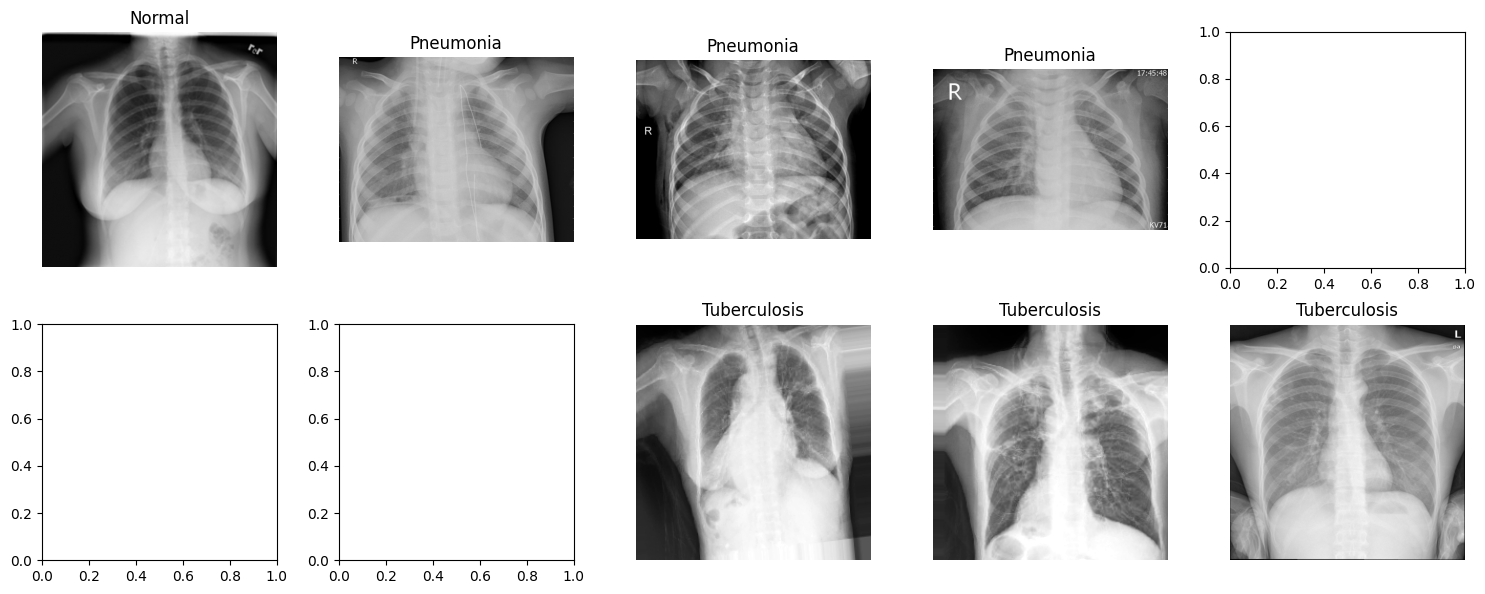

In [25]:
import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(['Normal', 'Pneumonia', 'Tuberculosis']):
    folder = f"{BASE_DIR}/{cls}"
    files  = os.listdir(folder)
    sample = random.sample(files, min(3, len(files)))
    for j, fname in enumerate(sample):
        if i*3+j < 10:
            img = plt.imread(os.path.join(folder, fname))
            axes[i//2][i%5 + j].imshow(img, cmap='gray')
            axes[i//2][i%5 + j].set_title(cls)
            axes[i//2][i%5 + j].axis('off')
plt.tight_layout()
plt.show()

In [26]:
from PIL import Image

def remove_corrupt_images(folder):
    removed = 0
    files = os.listdir(folder)
    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath)
            arr = np.array(img)
            # সাদা বা কালো blank image check
            if arr.mean() > 250 or arr.mean() < 5 or arr.std() < 5:
                os.remove(fpath)
                removed += 1
        except:
            os.remove(fpath)
            removed += 1
    return removed

print("🧹 Cleaning corrupt/blank images...")
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    folder = f"{BASE_DIR}/{cls}"
    removed = remove_corrupt_images(folder)
    count   = len(os.listdir(folder))
    print(f"  {cls}: removed {removed}, remaining {count}")

🧹 Cleaning corrupt/blank images...
  Normal: removed 0, remaining 3000
  Pneumonia: removed 0, remaining 3000
  Tuberculosis: removed 0, remaining 3000


In [28]:
from PIL import Image
import matplotlib.pyplot as plt

# কিছু Normal image দেখো statistics সহ
folder = f"{BASE_DIR}/Normal"
files  = os.listdir(folder)[:20]

stats = []
for fname in files:
    fpath = os.path.join(folder, fname)
    img   = Image.open(fpath).convert('RGB')
    arr   = np.array(img)
    stats.append({
        'file': fname,
        'mean': arr.mean(),
        'std':  arr.std(),
        'min':  arr.min(),
        'max':  arr.max()
    })

df_stats = pd.DataFrame(stats)
print(df_stats.to_string())
print(f"\nMean range: {df_stats['mean'].min():.1f} - {df_stats['mean'].max():.1f}")
print(f"Std range:  {df_stats['std'].min():.1f} - {df_stats['std'].max():.1f}")

               file        mean        std  min  max
0     Normal_57.png  132.256630  69.480355    0  249
1   Normal_1041.png  105.881590  62.538259    0  255
2   Normal_2755.png  108.327122  61.885082    0  255
3    Normal_855.png  104.518395  62.828207    0  255
4   Normal_2170.png   97.956868  62.872052    0  252
5   Normal_3342.png  118.439268  69.240274    0  248
6   Normal_3467.png  138.934967  63.322798    0  255
7   Normal_1910.png  134.476225  57.534211    0  247
8   Normal_3437.png  110.583752  70.616050    0  247
9   Normal_2981.png  132.419481  71.720536    0  251
10  Normal_1837.png  151.620183  74.714469    0  250
11  Normal_4210.png  119.049910  58.574713    0  255
12  Normal_2405.png  127.683203  72.721728    0  250
13  Normal_2238.png  130.792967  67.389912    0  254
14  Normal_4457.png  135.542969  68.111939    0  251
15  Normal_3025.png  159.617991  59.420467    2  246
16  Normal_1761.png  116.797172  68.437022    0  251
17  Normal_1554.png  122.717565  53.693858    

In [1]:
# ── DenseNet121 preprocessing ──────────────────────────────────
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

# Generator এ rescale বাদ দাও, DenseNet এর নিজস্ব preprocessing use করো
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.75, 1.25],
    fill_mode='nearest'
)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)
val_data = val_gen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
test_data = val_gen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_data.class_indices.keys())
print("Classes:", CLASS_NAMES)

# ── DenseNet121 Model ──────────────────────────────────────────
def build_model(num_classes=3):
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = False
    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu',
               kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=base.input, outputs=output), base

model, base_model = build_model()
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# ── Phase 1 ────────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model.keras',
                    save_best_only=True, monitor='val_loss', verbose=1)
]

print("🚀 Phase 1: Training top layers...")
history1 = model.fit(
    train_data, validation_data=val_data,
    epochs=20, callbacks=callbacks,
    class_weight=class_weight_dict
)

# ── Phase 2: Fine-tuning ───────────────────────────────────────
print("\n🔧 Phase 2: Fine-tuning last 50 layers...")
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

callbacks_ft = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                      patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint('/kaggle/working/best_model_finetuned.keras',
                    save_best_only=True, monitor='val_loss', verbose=1)
]

history2 = model.fit(
    train_data, validation_data=val_data,
    epochs=30, callbacks=callbacks_ft,
    class_weight=class_weight_dict
)

model.save('/kaggle/working/final_model.keras')
print("\n✅ Training complete! Model saved.")

2026-06-03 06:53:43.798192: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780469623.974176      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780469624.032656      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780469624.455174      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780469624.455208      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780469624.455211      58 computation_placer.cc:177] computation placer alr

NameError: name 'ImageDataGenerator' is not defined

In [3]:
# ═══ FULL SETUP - সব এক cell এ ═══════════════════════════════

import os, shutil, numpy as np, pandas as pd, tensorflow as tf
import json
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

BASE_DIR         = "/kaggle/working/chest_dataset"
RADIOGRAPHY_PATH = "/kaggle/input/datasets/tawsifurrahman/covid19-radiography-database/COVID-19_Radiography_Dataset"
PNEUMONIA_PATH   = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray"
TB_PATH          = "/kaggle/input/datasets/usmanshams/tbx-11/TBX11K"
IMG_SIZE         = 224
BATCH_SIZE       = 32

for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    os.makedirs(f"{BASE_DIR}/{cls}", exist_ok=True)

# ── copy function ──────────────────────────────────────────────
def copy_images(src, dest_cls, max_images=None):
    ext = {'.jpg','.jpeg','.png'}
    n   = 0
    for root, _, files in os.walk(src):
        for f in files:
            if os.path.splitext(f)[1].lower() in ext:
                dst = os.path.join(BASE_DIR, dest_cls, f"{dest_cls}_{n}{os.path.splitext(f)[1]}")
                if not os.path.exists(dst):
                    shutil.copy2(os.path.join(root, f), dst)
                n += 1
                if max_images and n >= max_images: return n
    return n

# ── TB: JSON থেকে correct images ──────────────────────────────
tb_dir   = f"{BASE_DIR}/Tuberculosis"
existing = os.listdir(tb_dir)

if len(existing) < 500:
    tb_json = "/kaggle/input/datasets/usmanshams/tbx-11/TBX11K/annotations/json/TBX11K_train_only_tb.json"
    with open(tb_json) as f:
        tb_data = json.load(f)
    tb_files = {os.path.basename(i['file_name']) for i in tb_data['images']}
    
    copied = 0
    for root, _, files in os.walk(TB_PATH):
        for f in files:
            if f in tb_files:
                shutil.copy2(os.path.join(root,f),
                             os.path.join(tb_dir, f"TB_{copied}.png"))
                copied += 1
    print(f"TB copied: {copied}")

    # Augment to 3000
    aug = ImageDataGenerator(rotation_range=15, horizontal_flip=True,
                             zoom_range=0.1, brightness_range=[0.8,1.2],
                             fill_mode='nearest')
    existing = os.listdir(tb_dir)
    ac, needed = 0, 3000 - copied
    idx = 0
    while ac < needed:
        img = load_img(os.path.join(tb_dir, existing[idx % len(existing)]),
                       target_size=(IMG_SIZE, IMG_SIZE))
        x = np.expand_dims(img_to_array(img), 0)
        for b in aug.flow(x, batch_size=1):
            tf.keras.preprocessing.image.save_img(
                os.path.join(tb_dir, f"TB_aug_{ac}.png"), b[0])
            ac += 1
            break
        idx += 1
    print(f"TB augmented: {ac}")

# ── Normal & Pneumonia ─────────────────────────────────────────
TARGET = 3000
if len(os.listdir(f"{BASE_DIR}/Normal")) < TARGET:
    n = copy_images(os.path.join(RADIOGRAPHY_PATH,"Normal","images"), 'Normal', TARGET)
    print(f"Normal: {n}")
if len(os.listdir(f"{BASE_DIR}/Pneumonia")) < TARGET:
    p = copy_images(os.path.join(PNEUMONIA_PATH,"train","PNEUMONIA"), 'Pneumonia', TARGET)
    print(f"Pneumonia: {p}")

# ── Balance to exactly 3000 ────────────────────────────────────
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    folder = f"{BASE_DIR}/{cls}"
    files  = os.listdir(folder)
    if len(files) > TARGET:
        for f in files[TARGET:]:
            os.remove(os.path.join(folder, f))

print("\n📊 Distribution:")
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    print(f"  {cls}: {len(os.listdir(f'{BASE_DIR}/{cls}'))}")

# ── DataFrame + Split ──────────────────────────────────────────
records = []
for cls in ['Normal', 'Pneumonia', 'Tuberculosis']:
    for f in os.listdir(f"{BASE_DIR}/{cls}"):
        if f.endswith(('.jpg','.jpeg','.png')):
            records.append({'filepath': f"{BASE_DIR}/{cls}/{f}", 'label': cls})

df = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# ── Generators ─────────────────────────────────────────────────
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20, width_shift_range=0.15,
    height_shift_range=0.15, horizontal_flip=True,
    zoom_range=0.15, shear_range=0.1,
    brightness_range=[0.75, 1.25], fill_mode='nearest'
)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True)
val_data = val_gen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)
test_data = val_gen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False)

CLASS_NAMES = list(train_data.class_indices.keys())
print("Classes:", CLASS_NAMES)

# ── Class weights ──────────────────────────────────────────────
classes = np.unique(train_df['label'])
weights = compute_class_weight('balanced', classes=classes, y=train_df['label'])
class_weight_dict = {train_data.class_indices[c]: w
                     for c, w in zip(classes, weights)}
print("Weights:", class_weight_dict)

# ── Model ──────────────────────────────────────────────────────
base = DenseNet121(weights='imagenet', include_top=False,
                   input_shape=(IMG_SIZE,IMG_SIZE,3))
base.trainable = False
x = GlobalAveragePooling2D()(base.output)
x = BatchNormalization()(x)
x = Dense(256, activation='relu',
           kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu',
           kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)
model  = Model(inputs=base.input, outputs=output)

model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.AUC(name='auc'),
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

# ── Phase 1 ────────────────────────────────────────────────────
cb1 = [EarlyStopping('val_loss', patience=7, restore_best_weights=True),
       ReduceLROnPlateau('val_loss', factor=0.3, patience=3, min_lr=1e-7),
       ModelCheckpoint('/kaggle/working/best_model.keras',
                       save_best_only=True, monitor='val_loss')]

print("\n🚀 Phase 1...")
h1 = model.fit(train_data, validation_data=val_data, epochs=15,
               callbacks=cb1, class_weight=class_weight_dict)

# ── Phase 2 ────────────────────────────────────────────────────
base.trainable = True
for layer in base.layers[:-50]:
    layer.trainable = False

model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy',
              metrics=['accuracy',
                       tf.keras.metrics.AUC(name='auc'),
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall')])

cb2 = [EarlyStopping('val_loss', patience=10, restore_best_weights=True),
       ReduceLROnPlateau('val_loss', factor=0.2, patience=4, min_lr=1e-8),
       ModelCheckpoint('/kaggle/working/best_model_finetuned.keras',
                       save_best_only=True, monitor='val_loss')]

print("\n🔧 Phase 2...")
h2 = model.fit(train_data, validation_data=val_data, epochs=20,
               callbacks=cb2, class_weight=class_weight_dict)

model.save('/kaggle/working/final_model.keras')
print("\n✅ Done! Model saved.")

TB copied: 599
TB augmented: 2401
Normal: 3000
Pneumonia: 3000

📊 Distribution:
  Normal: 3000
  Pneumonia: 3000
  Tuberculosis: 3000
Train: 6300 | Val: 1350 | Test: 1350
Found 6300 validated image filenames belonging to 3 classes.
Found 1350 validated image filenames belonging to 3 classes.
Found 1350 validated image filenames belonging to 3 classes.
Classes: ['Normal', 'Pneumonia', 'Tuberculosis']
Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


I0000 00:00:1780470194.321545      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780470194.327452      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🚀 Phase 1...
Epoch 1/15


I0000 00:00:1780470211.855380     129 service.cc:152] XLA service 0x787c8c0212f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780470211.855430     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780470211.855437     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780470215.302773     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/197 ━━━━━━━━━━━━━━━━━━━━ 1:36:46 30s/step - accuracy: 0.4062 - auc: 0.5422 - loss: 2.1335 - precision: 0.3600 - recall: 0.2812

I0000 00:00:1780470228.487375     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


197/197 ━━━━━━━━━━━━━━━━━━━━ 162s 674ms/step - accuracy: 0.9151 - auc: 0.9862 - loss: 0.6554 - precision: 0.9218 - recall: 0.9095 - val_accuracy: 0.9741 - val_auc: 0.9987 - val_loss: 0.4587 - val_precision: 0.9783 - val_recall: 0.9696 - learning_rate: 0.0010
Epoch 2/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 96s 488ms/step - accuracy: 0.9611 - auc: 0.9956 - loss: 0.4552 - precision: 0.9629 - recall: 0.9594 - val_accuracy: 0.9837 - val_auc: 0.9992 - val_loss: 0.3693 - val_precision: 0.9859 - val_recall: 0.9837 - learning_rate: 0.0010
Epoch 3/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 95s 481ms/step - accuracy: 0.9673 - auc: 0.9966 - loss: 0.3876 - precision: 0.9682 - recall: 0.9660 - val_accuracy: 0.9867 - val_auc: 0.9996 - val_loss: 0.3116 - val_precision: 0.9874 - val_recall: 0.9867 - learning_rate: 0.0010
Epoch 4/15
197/197 ━━━━━━━━━━━━━━━━━━━━ 97s 492ms/step - accuracy: 0.9687 - auc: 0.9967 - loss: 0.3380 - precision: 0.9695 - recall: 0.9675 - val_accuracy: 0.9770 - val_auc: 0.9981 - val_loss: 0.2979 - v

📊 Test Set Evaluation:
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 133ms/step - accuracy: 0.9948 - auc: 0.9996 - loss: 0.1035 - precision: 0.9956 - recall: 0.9948
  loss: 0.1035
  compile_metrics: 0.9948
43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 394ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       450
   Pneumonia       0.98      1.00      0.99       450
Tuberculosis       1.00      0.99      1.00       450

    accuracy                           0.99      1350
   macro avg       0.99      0.99      0.99      1350
weighted avg       0.99      0.99      0.99      1350



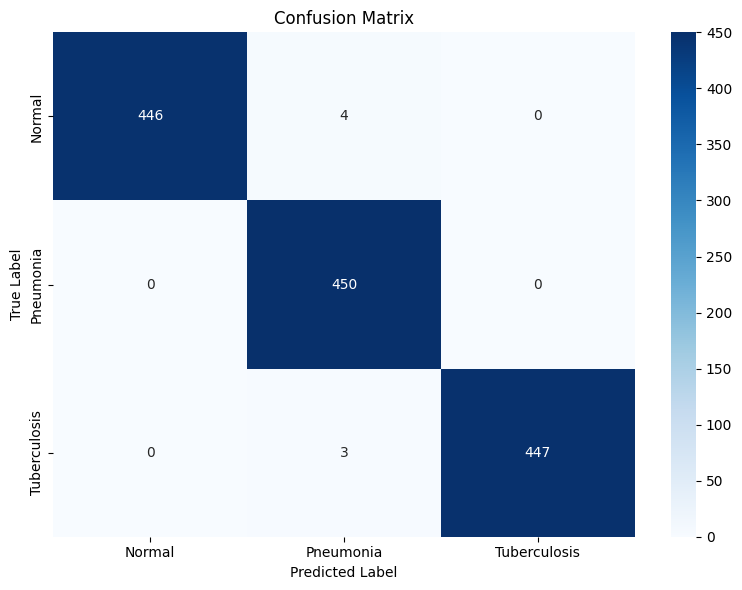

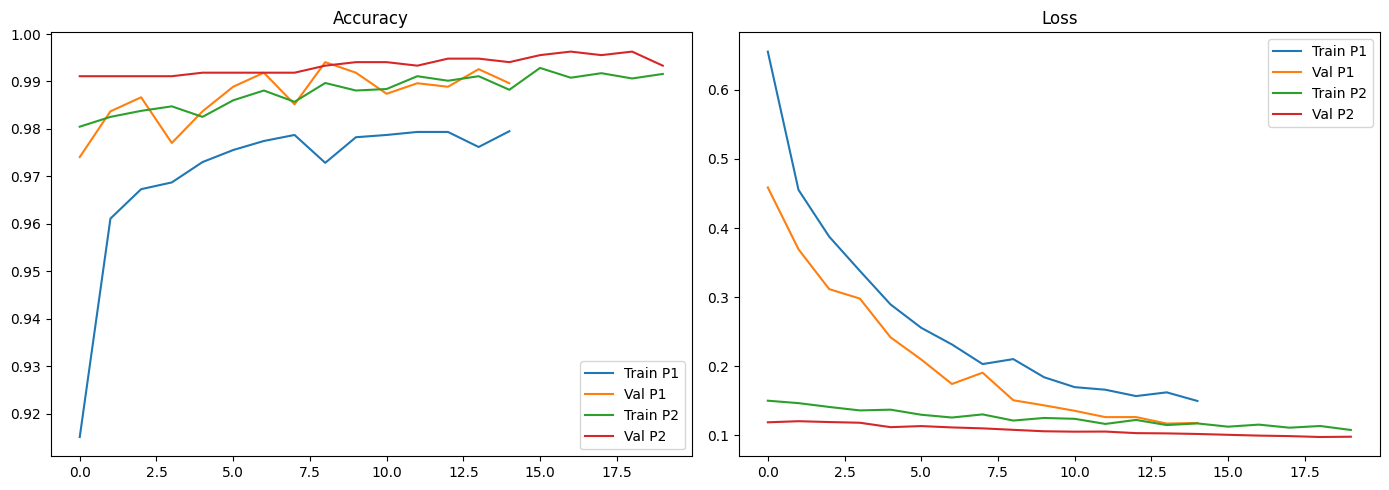

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


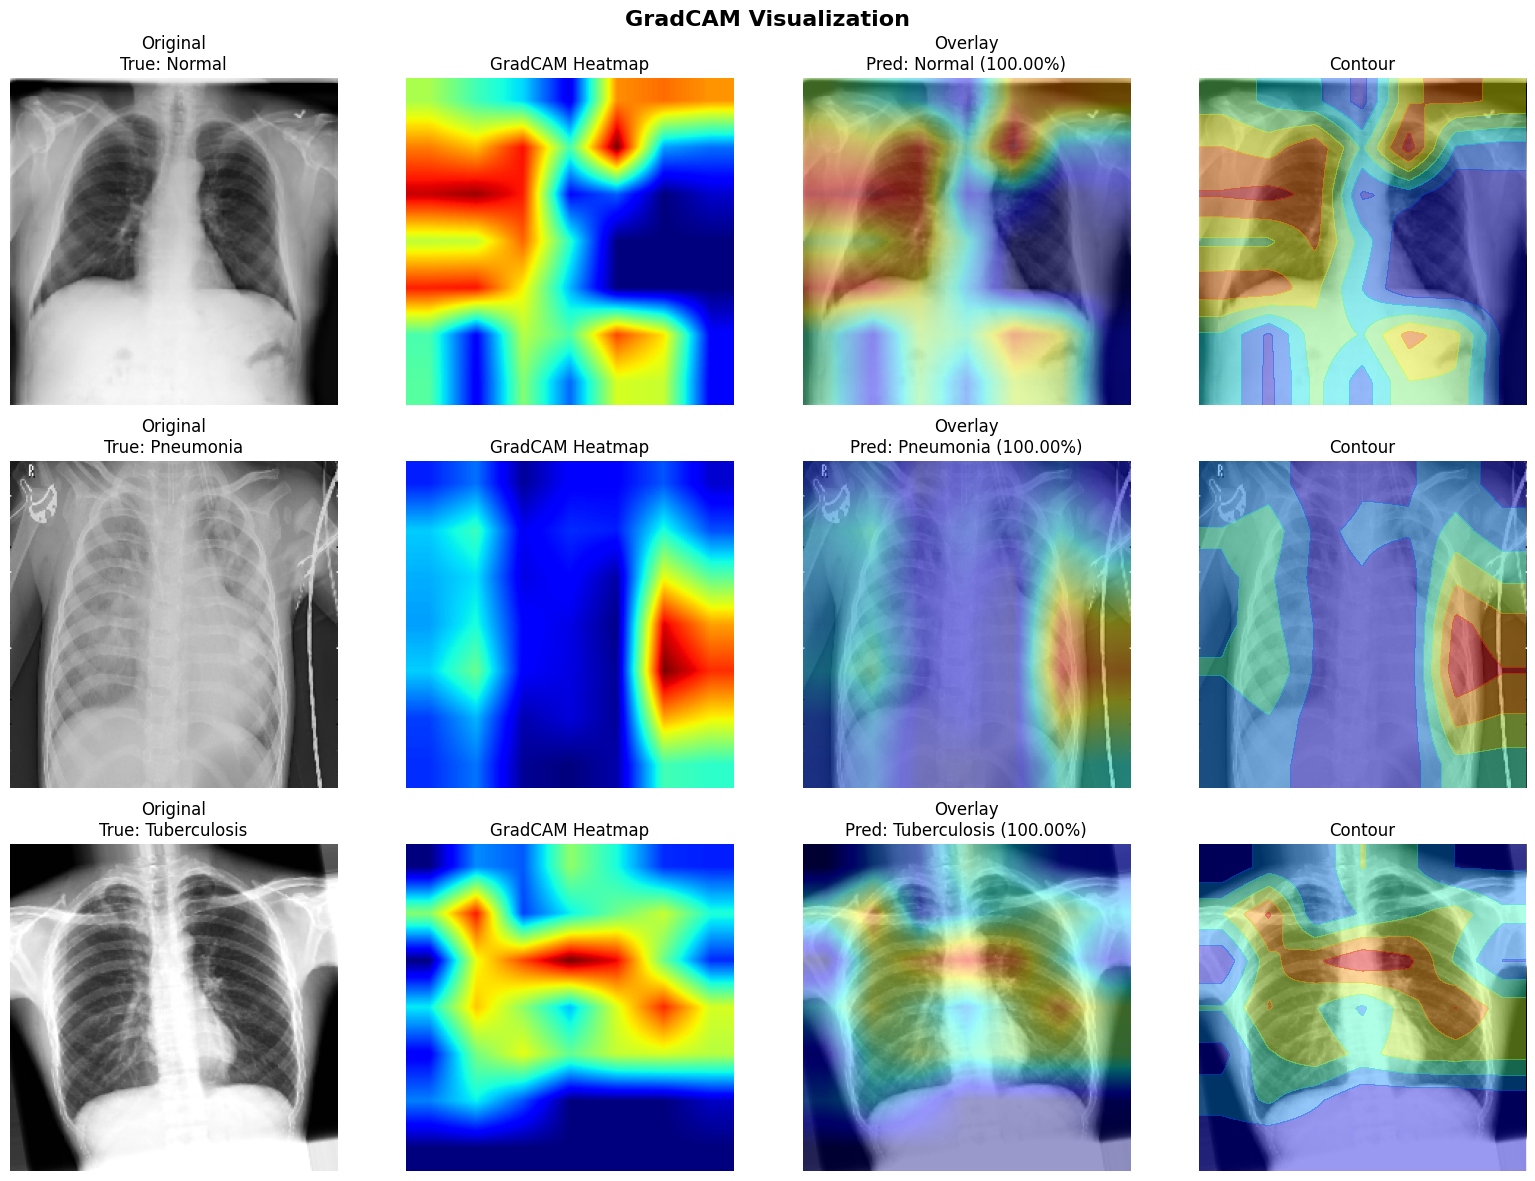


✅ Evaluation + GradCAM complete!


In [4]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Test Set Evaluation ────────────────────────────────────────
print("📊 Test Set Evaluation:")
results = model.evaluate(test_data, verbose=1)
for name, val in zip(model.metrics_names, results):
    print(f"  {name}: {val:.4f}")

# ── Classification Report ──────────────────────────────────────
test_data.reset()
y_pred_prob = model.predict(test_data, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_data.classes

print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

# ── Training History Plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Accuracy
axes[0].plot(h1.history['accuracy'],     label='Train P1')
axes[0].plot(h1.history['val_accuracy'], label='Val P1')
axes[0].plot(h2.history['accuracy'],     label='Train P2')
axes[0].plot(h2.history['val_accuracy'], label='Val P2')
axes[0].set_title('Accuracy')
axes[0].legend()
# Loss
axes[1].plot(h1.history['loss'],     label='Train P1')
axes[1].plot(h1.history['val_loss'], label='Val P1')
axes[1].plot(h2.history['loss'],     label='Train P2')
axes[1].plot(h2.history['val_loss'], label='Val P2')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150)
plt.show()

# ── GradCAM ───────────────────────────────────────────────────
def make_gradcam(img_array, model, last_conv='conv5_block16_2_conv'):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        pred_idx  = tf.argmax(preds[0])
        pred_score = preds[:, pred_idx]

    grads   = tape.gradient(pred_score, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    cam     = conv_out[0] @ pooled[..., tf.newaxis]
    cam     = tf.squeeze(cam)
    cam     = np.maximum(cam, 0) / (np.max(cam) + 1e-8)
    return cam, int(pred_idx), float(tf.reduce_max(preds))

# ── GradCAM visualization ──────────────────────────────────────
from tensorflow.keras.applications.densenet import preprocess_input as dn_preprocess

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, cls in enumerate(CLASS_NAMES):
    # ওই class এর একটা test image নাও
    cls_indices = [j for j, c in enumerate(test_data.classes)
                   if c == train_data.class_indices[cls]]
    idx      = cls_indices[0]
    img_path = test_df.iloc[idx]['filepath']

    # Original image
    orig = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    orig_arr = img_to_array(orig)

    # Preprocess
    img_array = np.expand_dims(dn_preprocess(orig_arr.copy()), axis=0)

    # GradCAM
    cam, pred_idx, conf = make_gradcam(img_array, model)
    cam_resized = np.array(
        tf.image.resize(cam[..., np.newaxis], (IMG_SIZE, IMG_SIZE))
    ).squeeze()

    # Heatmap overlay
    heatmap = cm_module = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = (orig_arr / 255.0) * 0.6 + heatmap * 0.4

    axes[i][0].imshow(orig_arr.astype('uint8'), cmap='gray')
    axes[i][0].set_title(f'Original\nTrue: {cls}')
    axes[i][0].axis('off')

    axes[i][1].imshow(cam_resized, cmap='jet')
    axes[i][1].set_title('GradCAM Heatmap')
    axes[i][1].axis('off')

    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f'Overlay\nPred: {CLASS_NAMES[pred_idx]} ({conf:.2%})')
    axes[i][2].axis('off')

    axes[i][3].imshow(orig_arr.astype('uint8'), cmap='gray')
    axes[i][3].contourf(cam_resized, alpha=0.4, cmap='jet')
    axes[i][3].set_title('Contour')
    axes[i][3].axis('off')

plt.suptitle('GradCAM Visualization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/gradcam.png', dpi=150)
plt.show()
print("\n✅ Evaluation + GradCAM complete!")

In [8]:
import ipywidgets as widgets
from IPython.display import display
import io

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

def on_upload(change):
    import numpy as np
    import tensorflow as tf
    import matplotlib.pyplot as plt
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    from tensorflow.keras.applications.densenet import preprocess_input
    from PIL import Image
    
    IMG_SIZE    = 224
    CLASS_NAMES = ['Normal', 'Pneumonia', 'Tuberculosis']
    
    # ── Image load ─────────────────────────────────────────────
    file_content = list(uploader.value.values())[0]['content']
    orig = Image.open(io.BytesIO(file_content)).convert('RGB')
    orig = orig.resize((IMG_SIZE, IMG_SIZE))
    orig_arr  = np.array(orig)
    img_input = np.expand_dims(preprocess_input(orig_arr.copy().astype('float32')), axis=0)

    # ── Prediction ─────────────────────────────────────────────
    preds      = model.predict(img_input, verbose=0)[0]
    pred_idx   = np.argmax(preds)
    pred_class = CLASS_NAMES[pred_idx]
    confidence = preds[pred_idx]

    # ── GradCAM ────────────────────────────────────────────────
    def make_gradcam(img_array, model, last_conv='conv5_block16_2_conv'):
        grad_model = tf.keras.models.Model(
            inputs=model.input,
            outputs=[model.get_layer(last_conv).output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_out, preds_out = grad_model(img_array)
            top_class = tf.argmax(preds_out[0])
            score     = preds_out[:, top_class]
        grads  = tape.gradient(score, conv_out)
        pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
        cam    = conv_out[0] @ pooled[..., tf.newaxis]
        cam    = tf.squeeze(cam).numpy()
        cam    = np.maximum(cam, 0)
        cam    = cam / (cam.max() + 1e-8)
        return cam

    cam = make_gradcam(img_input, model)
    cam_resized = np.array(
        tf.image.resize(cam[..., np.newaxis], (IMG_SIZE, IMG_SIZE))
    ).squeeze()

    # ── Visualization ──────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(f'Prediction: {pred_class} ({confidence:.2%})',
                 fontsize=16, fontweight='bold',
                 color='green' if pred_class=='Normal' else 'red')

    axes[0].imshow(orig_arr, cmap='gray')
    axes[0].set_title('Original X-Ray')
    axes[0].axis('off')

    axes[1].imshow(cam_resized, cmap='jet')
    axes[1].set_title('GradCAM Heatmap')
    axes[1].axis('off')

    heatmap = plt.cm.jet(cam_resized)[:, :, :3]
    overlay = (orig_arr / 255.0) * 0.5 + heatmap * 0.5
    axes[2].imshow(np.clip(overlay, 0, 1))
    axes[2].set_title('Heatmap Overlay')
    axes[2].axis('off')

    colors = ['#2ecc71' if i == pred_idx else '#3498db'
              for i in range(len(CLASS_NAMES))]
    bars = axes[3].barh(CLASS_NAMES, preds * 100, color=colors)
    axes[3].set_xlim(0, 110)
    axes[3].set_xlabel('Probability (%)')
    axes[3].set_title('Class Probabilities')
    for bar, prob in zip(bars, preds):
        axes[3].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{prob:.2%}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig('/kaggle/working/prediction_result.png', dpi=150)
    plt.show()

    print("\n" + "="*50)
    if pred_class == 'Normal':
        print("✅ স্বাভাবিক ফুসফুস — কোনো রোগের লক্ষণ নেই")
    elif pred_class == 'Pneumonia':
        print("⚠️  নিউমোনিয়ার লক্ষণ পাওয়া গেছে — ডাক্তার দেখান")
    else:
        print("🔴 যক্ষ্মার (TB) লক্ষণ পাওয়া গেছে — অবিলম্বে ডাক্তার দেখান")
    print(f"   Confidence: {confidence:.2%}")
    print("="*50)

uploader.observe(on_upload, names='value')

FileUpload(value=(), accept='image/*', description='Upload')

In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tensorflow.keras.applications.densenet import preprocess_input
from PIL import Image
import ipywidgets as widgets
from IPython.display import display, clear_output
import io
import cv2

IMG_SIZE    = 224
CLASS_NAMES = ['Normal', 'Pneumonia', 'Tuberculosis']
out         = widgets.Output()
uploader    = widgets.FileUpload(accept='image/*', multiple=False)
btn         = widgets.Button(description='🔍 Analyze', button_style='success')

display(uploader, btn, out)

def analyze(_):
    with out:
        clear_output(wait=True)
        if not uploader.value:
            print("❌ আগে image upload করো!")
            return

        file_content = list(uploader.value)[0].content
        orig      = Image.open(io.BytesIO(bytes(file_content))).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        orig_arr  = np.array(orig)
        gray      = np.mean(orig_arr, axis=2)  # grayscale version
        img_input = np.expand_dims(preprocess_input(orig_arr.copy().astype('float32')), axis=0)

        preds      = model.predict(img_input, verbose=0)[0]
        pred_idx   = np.argmax(preds)
        pred_class = CLASS_NAMES[pred_idx]
        confidence = preds[pred_idx]

        # ── GradCAM ────────────────────────────────────────────
        grad_model = tf.keras.models.Model(
            inputs=model.input,
            outputs=[model.get_layer('conv5_block16_2_conv').output, model.output]
        )
        with tf.GradientTape() as tape:
            conv_out, preds_out = grad_model(img_input)
            score = preds_out[:, pred_idx]
        grads  = tape.gradient(score, conv_out)
        pooled = tf.reduce_mean(grads, axis=(0,1,2))
        cam    = tf.squeeze(conv_out[0] @ pooled[..., tf.newaxis]).numpy()
        cam    = np.maximum(cam, 0)
        cam    = cam / (cam.max() + 1e-8)

        # ── High quality resize with blur ──────────────────────
        cam_resized = np.array(
            tf.image.resize(cam[..., np.newaxis], (IMG_SIZE, IMG_SIZE))
        ).squeeze()
        # Gaussian blur দিয়ে smooth করো
        from scipy.ndimage import gaussian_filter
        cam_smooth = gaussian_filter(cam_resized, sigma=8)
        cam_smooth = cam_smooth / (cam_smooth.max() + 1e-8)

        # ── High threshold — শুধু top 30% area দেখাও ──────────
        threshold  = 0.5
        cam_thresh = np.where(cam_smooth > threshold, cam_smooth, 0)

        # ── Plot ───────────────────────────────────────────────
        fig = plt.figure(figsize=(22, 10))
        color_title = 'green' if pred_class == 'Normal' else '#e74c3c'

        # 1. Original
        ax1 = fig.add_subplot(1, 4, 1)
        ax1.imshow(gray, cmap='gray')
        ax1.set_title('Original X-Ray', fontsize=13, fontweight='bold')
        ax1.axis('off')

        # 2. Smooth Heatmap only on lung area
        ax2 = fig.add_subplot(1, 4, 2)
        ax2.imshow(gray, cmap='gray')
        ax2.imshow(cam_smooth, cmap='jet', alpha=0.55)
        ax2.set_title('Disease Heatmap\n(Red = High Risk Zone)', fontsize=13, fontweight='bold')
        ax2.axis('off')

        # 3. Thresholded — শুধু most suspicious area
        # শুধু এই অংশটা replace করো plot এর মধ্যে

        # 3. Thresholded — শুধু most suspicious area
        ax3 = fig.add_subplot(1, 4, 3)
        ax3.imshow(gray, cmap='gray')
        ax3.set_title('Suspicious Region\n(Top Risk Area Only)', fontsize=13, fontweight='bold')
        ax3.axis('off')

        # শুধু হলুদ circle দেখাবে, color fill নেই
        y_coords, x_coords = np.where(cam_smooth > 0.75)
        if len(y_coords) > 0:
            cy, cx = int(np.mean(y_coords)), int(np.mean(x_coords))
            circle = plt.Circle((cx, cy), 30, color='yellow',
                                fill=False, linewidth=3, linestyle='--')
            ax3.add_patch(circle)
            ax3.annotate('⚠ Focus', (cx, cy-38), color='yellow',
                        fontsize=11, fontweight='bold', ha='center')

        # 4. Probability bar
        ax4 = fig.add_subplot(1, 4, 4)
        colors = ['#2ecc71' if i == pred_idx else '#bdc3c7' for i in range(3)]
        bars   = ax4.barh(CLASS_NAMES, preds*100, color=colors, height=0.5, edgecolor='white')
        ax4.set_xlim(0, 115)
        ax4.set_xlabel('Probability (%)', fontsize=12)
        ax4.set_title('Class Probabilities', fontsize=13, fontweight='bold')
        ax4.spines[['top','right']].set_visible(False)
        for bar, prob in zip(bars, preds):
            ax4.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                    f'{prob:.2%}', va='center', fontsize=12, fontweight='bold')

        fig.suptitle(f'Prediction: {pred_class}  |  Confidence: {confidence:.2%}',
                    fontsize=18, fontweight='bold', color=color_title, y=1.02)

        plt.tight_layout()
        plt.savefig('/kaggle/working/prediction_result.png', dpi=150, bbox_inches='tight')
        plt.show()

        # ── Diagnosis ──────────────────────────────────────────
        print("\n" + "="*55)
        if pred_class == 'Normal':
            print("✅ স্বাভাবিক ফুসফুস — কোনো রোগের লক্ষণ নেই")
            print("   Heatmap এ কোনো suspicious region দেখা যাচ্ছে না")
        elif pred_class == 'Pneumonia':
            print("⚠️  নিউমোনিয়ার লক্ষণ পাওয়া গেছে")
            print("   Heatmap এ যে লাল অংশ দেখছেন সেখানে infection সম্ভাবনা বেশি")
            print("   অবিলম্বে ডাক্তার দেখান")
        else:
            print("🔴 যক্ষ্মার (TB) লক্ষণ পাওয়া গেছে")
            print("   Heatmap এ যে লাল/হলুদ circle দেখছেন সেটাই suspicious spot")
            print("   অবিলম্বে বিশেষজ্ঞ ডাক্তার দেখান")
        print(f"   Confidence: {confidence:.2%}")
        print("="*55)
        print("\n⚠️  এটি শুধুমাত্র AI সহায়তা — চিকিৎসকের পরামর্শ নিন।")

btn.on_click(analyze)

FileUpload(value=(), accept='image/*', description='Upload')

Button(button_style='success', description='🔍 Analyze', style=ButtonStyle())

Output()